# A simple Rietveld refinement

We refine the fluorapatite structure against the pattern notebook 01 fitted with Le Bail.
This time the peak intensities come from the atoms, so the fit can move them.
Along the way we look at the plan's stages, the parameter table, two parameters the data cannot tell apart, and a constraint between three atoms.

**You need** `pip install "rietx[viz]"`.
Notebook 01 introduces the pattern and how to read a fit's summary.

**The data** is `FAP.XRA` from the GSAS-II `LabData` tutorial, with a CIF transcribed from the same tutorial's experiment file.
Both ship with rietx.
Fluorapatite, Ca₅(PO₄)₃F, has seven atomic sites in space group P6₃/m.

**Runtime** is under a minute on a laptop.

## A first refinement

This is the example on the rietx home page.

In [1]:
import rietx as rx
from rietx.examples import examples_dir

data = rx.read_pattern(examples_dir() / "FAP.XRA")
structure = rx.Structure.from_cif(examples_dir() / "fluorapatite.cif")
instrument = rx.Instrument.bragg_brentano(radiation="CuKa")
instrument.geometry.axial_sl.value = 0.02  # axial divergence
instrument.geometry.axial_hl.value = 0.02
instrument.background = rx.BackgroundChebyshev.with_terms(6)

ref = rx.Refinement(structure, instrument)
result = ref.fit(data, plan="mccusker_structural", two_theta_limits=(15, 130))

print(f"{result.status}  Rwp={result.statistics.rwp:.4f}  "
      f"GoF={result.statistics.gof:.2f}")
for name in ("a", "c"):
    p = result.parameter(f"phases.0.cell.{name}")
    print(f"  {name} = {p.value:.5f} +/- {p.stderr:.5f} A")
for d in result.diagnostics:
    print(f"  [{d.level}] {d.code}: {d.message}")

converged  Rwp=0.0893  GoF=1.60
  a = 9.37228 +/- 0.00008 A
  c = 6.88626 +/- 0.00008 A
  [warning] SITE_SNAPPED_TO_SPECIAL_POSITION: 1 site(s) in phase 'fluorapatite' sit within 0.0001 of a special position of 'P 63/m' without being on it, and were expanded at it: Ca1 (3.3e-11 → multiplicity 4). Largest shift 3.33e-11 in fractional coordinates
  [warning] RESOLUTION_UNCONSTRAINED: U, V, W refined on a predominantly Lorentzian pattern (Γ_L exceeds Γ_G at 4786 of 5751 fitted points; the Gaussian carries 41% of the width) — on a pattern of this character the Gaussian resolution terms are not determined by the data, so what they converged to is a fitted artefact rather than a measurement of the instrument
  [warning] PATTERN_UNDERSAMPLED: 4.6 steps across the FWHM (median over 76 fitted peaks) — below the 5 the guidelines ask for


Three warnings came back.

- `SITE_SNAPPED_TO_SPECIAL_POSITION`: the CIF gives Ca1's x as 0.3333333333, which is 1/3 to ten digits. The reader placed it exactly on the special position.
- `RESOLUTION_UNCONSTRAINED`: the peaks are mostly Lorentzian, so the Gaussian width terms U, V and W are poorly determined. Do not quote them.
- `PATTERN_UNDERSAMPLED`: the step count notebook 01 measured.

None of them invalidates the structure, but each one limits what you can quote.

## The plan and its stages

A plan frees parameters in groups, in a fixed order, and runs each group to convergence before freeing the next.
The order follows McCusker et al. (1999): background and scale, then zero shift, cell and peak widths, then atomic coordinates and displacement parameters.
Freeing everything at once from a poor start tends to land in a wrong minimum.

In [2]:
print(rx.PLAN_INFO["mccusker_structural"].description)
for stage in result.stages:
    print(f"{stage.name:22} {stage.status:10} {len(stage.freed):3} freed")

The standard order continued into the structure: coordinates as site-symmetry DOFs, then displacement parameters (biso or the anisotropic patterns, whichever each site declares), then preferred orientation, extinction and surface roughness where declared.
scale_bkg              converged    7 freed
zero                   converged    1 freed
cell                   converged    2 freed
profile_w              converged    1 freed
profile                converged    4 freed
extra_components       converged    0 freed
coordinates            converged   12 freed
biso                   converged    7 freed
preferred_orientation  converged    0 freed
extinction             converged    1 freed
roughness              converged    0 freed


A stage that frees nothing belongs to a correction this model does not declare, such as preferred orientation.
It converges at once and changes nothing.

## The parameter table

`ref.parameters()` lists every parameter the model has, whether it varies or not.
Here are the rows for one oxygen site, O7, which sits on a general position.

In [3]:
for row in ref.parameters():
    if row.path.startswith("phases.0.atoms.6."):
        state = "varies" if row.vary else (row.held_because or "fixed")
        esd = f"{row.esd:.5f}" if row.esd is not None else "-"
        print(f"{row.path:28} {row.value:10.5f}  esd {esd:8}  {state}")

phases.0.atoms.6.x              0.33986  esd 0.00063   tied: = 0.339862 + 1·phases.0.atoms.6.dof.0
phases.0.atoms.6.y              0.25772  esd 0.00061   tied: = 0.25772 + 1·phases.0.atoms.6.dof.1
phases.0.atoms.6.z              0.07048  esd 0.00061   tied: = 0.0704785 + 1·phases.0.atoms.6.dof.2
phases.0.atoms.6.dof.0          0.00000  esd 0.00063   varies
phases.0.atoms.6.dof.1          0.00000  esd 0.00061   varies
phases.0.atoms.6.dof.2          0.00000  esd 0.00061   varies
phases.0.atoms.6.occ            1.00000  esd -         fixed
phases.0.atoms.6.biso           0.38547  esd 0.10865   varies


The atom's x, y and z are not refined directly.
rietx refines one `dof` per direction the site symmetry allows.
O7 is on a general position, so it has three.
An atom on a mirror plane has two, and one on a three-fold axis has one.
The coordinates follow from the `dof` values, so the symmetry always holds.

## Two parameters the data cannot separate

A flat-plate diffractometer has two corrections that shift every peak: the zero shift (constant in 2θ) and the specimen displacement (proportional to cos θ).
The `lab_bragg_brentano` plan frees both.
Run it from where the first fit ended and see what happens.

In [4]:
both = ref.fit(data, plan="lab_bragg_brentano", two_theta_limits=(15, 130))
for path in ("instrument.zero_shift", "instrument.geometry.sample_displacement", "phases.0.cell.a"):
    p = both.parameter(path)
    print(f"{path:40} {p.value:9.5f} +/- {p.stderr:.5f}")
for d in both.diagnostics:
    if d.code == "HIGH_CORRELATION" and "instrument.zero_shift" in d.where:
        print(f"[{d.level}] {d.code}: {d.message.split(' — ')[0]}")

instrument.zero_shift                     -0.16454 +/- 0.03711
instrument.geometry.sample_displacement   -0.23099 +/- 0.06638
phases.0.cell.a                            9.36900 +/- 0.00098
[warning] HIGH_CORRELATION: instrument.zero_shift ~ instrument.geometry.sample_displacement (ρ=+1.000)
[warning] HIGH_CORRELATION: phases.0.cell.a ~ instrument.zero_shift (ρ=+0.997)
[warning] HIGH_CORRELATION: phases.0.cell.c ~ instrument.zero_shift (ρ=+0.995)


The zero shift and the displacement are correlated at ρ = 1.000.
The fit could trade one against the other without changing the pattern, so neither value is a measurement.
The cell's esd grew too, because the cell shifts peaks in a similar way.

The cure is to hold one of the pair at a value known from outside this fit.
GSAS's own refinement of this file held the zero shift at 0 and refined the displacement.
We do the same.
First go back to the first fit: every fit is a node in the refinement's history, and `checkout` restores one.

In [5]:
ref.checkout(result.node_id)
ref.set_values({"instrument.zero_shift": 0.0})
ref.hold(["instrument.zero_shift"])

held = ref.fit(data, plan="lab_bragg_brentano", two_theta_limits=(15, 130))
for path in ("instrument.geometry.sample_displacement", "phases.0.cell.a"):
    p = held.parameter(path)
    print(f"{path:40} {p.value:9.5f} +/- {p.stderr:.5f}")
for d in held.diagnostics:
    if d.code == "HOLD_BLOCKED_PLAN":
        print(f"[{d.level}] {d.code}: {d.message}")

instrument.geometry.sample_displacement    0.06322 +/- 0.00146
phases.0.cell.a                            9.37331 +/- 0.00008
[info] HOLD_BLOCKED_PLAN: 1 held parameter was matched by the turn_on glob of stage 'zero_disp' and stayed fixed: instrument.zero_shift. The hold you declared outranks the plan's glob


The displacement now has a small esd, and so does the cell.
`HOLD_BLOCKED_PLAN` reports that the plan tried to free the zero shift and the hold stopped it.

Use `ref.hold` for this, not `vary=False` on the parameter.
A plan sets which parameters vary at each stage, so it would free a parameter marked `vary=False`.
A hold outranks the plan.

## A constraint between three atoms

Fluorapatite has three oxygen sites in its phosphate group: O5, O6 and O7.
Their displacement parameters (Biso, the mean-square vibration amplitude times 8π²) are expected to be similar.
Check that against the data before constraining anything.

In [6]:
OXYGENS = ["phases.0.atoms.4.biso", "phases.0.atoms.5.biso", "phases.0.atoms.6.biso"]
for path in OXYGENS:
    p = result.parameter(path)
    print(f"{path:24} {p.value:.3f} +/- {p.stderr:.3f} Å²")

phases.0.atoms.4.biso    0.264 +/- 0.149 Å²
phases.0.atoms.5.biso    0.467 +/- 0.157 Å²
phases.0.atoms.6.biso    0.385 +/- 0.109 Å²


Each value lies within about one esd of the others.
The data cannot tell them apart, so refining one shared value loses nothing and spends two fewer parameters.
`tie_equal` makes the second and third follow the first.

In [7]:
ref.tie_equal(OXYGENS)
final = ref.fit(data, plan="mccusker_structural", two_theta_limits=(15, 130))

print(f"free parameters: {result.statistics.n_free_parameters} before, "
      f"{final.statistics.n_free_parameters} after")
p = final.parameter(OXYGENS[0])
print(f"shared oxygen Biso: {p.value:.3f} +/- {p.stderr:.3f} Å²")
print(f"Rwp: {result.statistics.rwp:.4f} before, {final.statistics.rwp:.4f} after")

free parameters: 35 before, 32 after
shared oxygen Biso: 0.383 +/- 0.077 Å²
Rwp: 0.0893 before, 0.0890 after


The count fell by three: two for the tie, and one for the zero shift held above.
The shared esd is smaller than any of the three separate ones.
That is what the constraint bought.
Rwp barely moved, and it could not have shown the gain: a constraint is judged by its premise and its esds.

## Is the structure chemically sensible?

A fit can match the pattern with atoms in impossible places.
`result.geometry` lists the bonds the refined structure implies, with esds.
A phosphate's P–O bonds are close to 1.54 Å.

In [8]:
for bond in final.geometry.bonds:
    if bond.atom_1 == "P3" and bond.atom_2.startswith("O"):
        print(f"{bond.atom_1}-{bond.atom_2}  {bond.distance:.3f} +/- {bond.stderr:.3f} Å")

P3-O7  1.526 +/- 0.005 Å
P3-O7  1.526 +/- 0.005 Å
P3-O5  1.553 +/- 0.007 Å
P3-O6  1.574 +/- 0.006 Å


The list has one row per bond, and O7 sits on both sides of the mirror plane, so it appears twice.
All four bonds are within 0.04 Å of 1.54 Å.
That is chemically sensible, but some differ from it by several esds.
An esd counts only the noise in the data, and not errors in the model, so a real structure can sit further from a reference than its esd suggests.

## The history

Every stage of every fit is a node you can return to.

In [9]:
print(ref.history.summary())

tcb8d2285  40 nodes  data=FAP.XRA
 n0000  root                   —
└─  n0001  stage:scale_bkg        Rwp 0.5704
   └─  n0002  stage:zero             Rwp 0.4556
      └─  n0003  stage:cell             Rwp 0.4545
         └─  n0004  stage:profile_w        Rwp 0.1941
            └─  n0005  stage:profile          Rwp 0.0939
               └─  n0006  stage:extra_components Rwp 0.0897
                  └─  n0007  stage:coordinates      Rwp 0.0895
                     └─  n0008  stage:biso             Rwp 0.0893
                        └─  n0009  stage:preferred_orientation Rwp 0.0893
                           └─  n0010  stage:extinction       Rwp 0.0893
                              └─  n0011  stage:roughness        Rwp 0.0893
                                 ├─  n0012  stage:scale_bkg        Rwp 0.0893
                                 │  └─  n0013  stage:zero_disp        Rwp 0.0893
                                 │     └─  n0014  stage:cell             Rwp 0.0889
                         

## The verdict for a declared purpose

What counts as finished depends on what the fit is for.
`ref.summary` prints the rows that decide a given deliverable.
Here the deliverable is the structure.

In [10]:
print(ref.summary(deliverable="structure"))

Refinement.summary: converged (rietveld)
  stage scale_bkg: converged (3 it, ftol=1e-06)
  stage zero: converged (2 it, ftol=1e-06)
  stage cell: converged (2 it, ftol=1e-06)
  stage profile_w: converged (3 it, ftol=1e-06)
  stage profile: converged (3 it, ftol=1e-06)
  stage extra_components: converged (2 it, ftol=1e-06)
  stage coordinates: converged (3 it, ftol=1e-06)
  stage biso: converged (4 it, ftol=1e-06)
  stage preferred_orientation: converged (2 it, ftol=1e-06)
  stage extinction: converged (5 it, ftol=1e-06)
  stage roughness: converged (5 it, ftol=solver default), max|Δθ|/esd=0.000
  diagnostics: 4 unresolved
    WARNING SITE_SNAPPED_TO_SPECIAL_POSITION: 1 site(s) in phase 'fluorapatite' sit within 0.0001 of a special position of 'P 63/m' without being on it, and were expanded at it: Ca1 (3.3e-11 → multiplicity 4). Largest shift 3.33e-11 in fractional coordinates — the stored coordinates are unchanged and the fit is unaffected, but the multiplicity is the special one — it 

The summary repeats the stages and diagnostics, then adds what needs the whole model.

- `layer0/1` reads the difference curve region by region and ranks the regions by their share of χ². When too little of the misfit sits in regions it can explain, it abstains from attributing a cause. An abstention is an answer: no single correction is indicated.
- `unmatched obs peaks` counts observed peaks with no reflection under them. Find them before quoting a structure, because a weak second phase would explain them.
- `next` names the parameter whose release the package predicts would help most, and the ΔBIC that release would have to pass.
- `exchangeability` lists held parameters whose effect a free one could imitate. The agent skill's rule 14 settles each with two short fits, one per rival.
- `protocol` is what you report alongside the numbers: the plan, what was held, and the observation count.

## The final fit

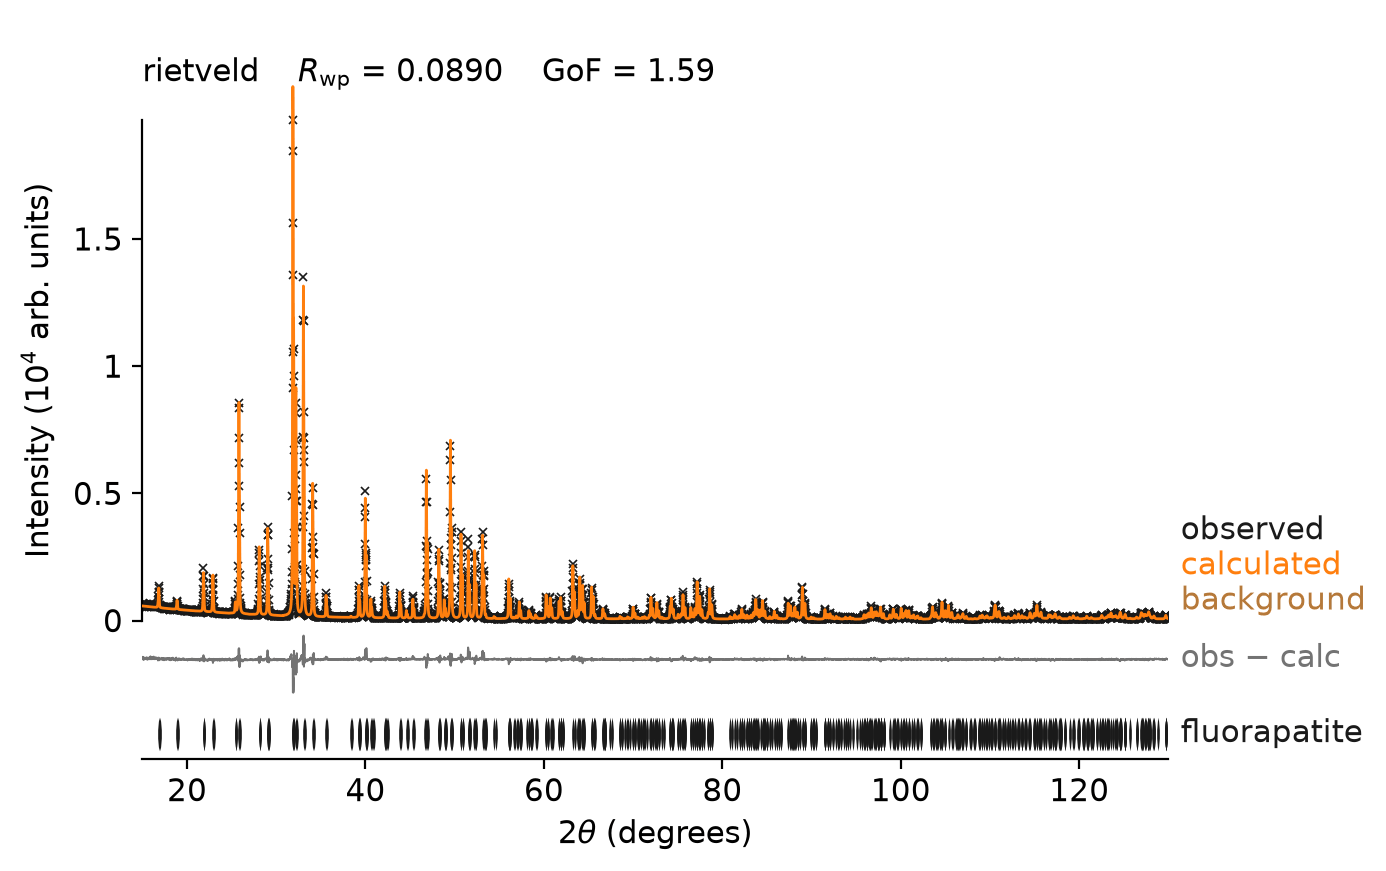

In [11]:
final.plot()

## Checking an agent's work

When an agent reports a structure refinement, check these in order.
The numbers are the rules in the rietx agent skill (`SKILL.md` §4).

- **Status and every diagnostic first** (rule 9). Ask which diagnostics limit what it quotes.
- **Correlations near 1** (§3, rule 7). Two parameters at ρ ≈ 1 are one measurement. Ask which was held, and what value it was held at.
- **Chemistry** (rule 12). Bond lengths and Biso values should be physically possible.
- **Constraints** (§3, rule 8). A tie needs its premise checked in an unconstrained fit first.
- **Rwp last** (rule 16), and only against a fit of the same channels.